Cargando la base maestra completa desde Gold...
Entrenando el modelo con variables de contexto y conectividad...

--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

         0.0       0.74      0.90      0.81     73169
         1.0       0.72      0.46      0.56     41555

    accuracy                           0.74    114724
   macro avg       0.73      0.68      0.69    114724
weighted avg       0.73      0.74      0.72    114724



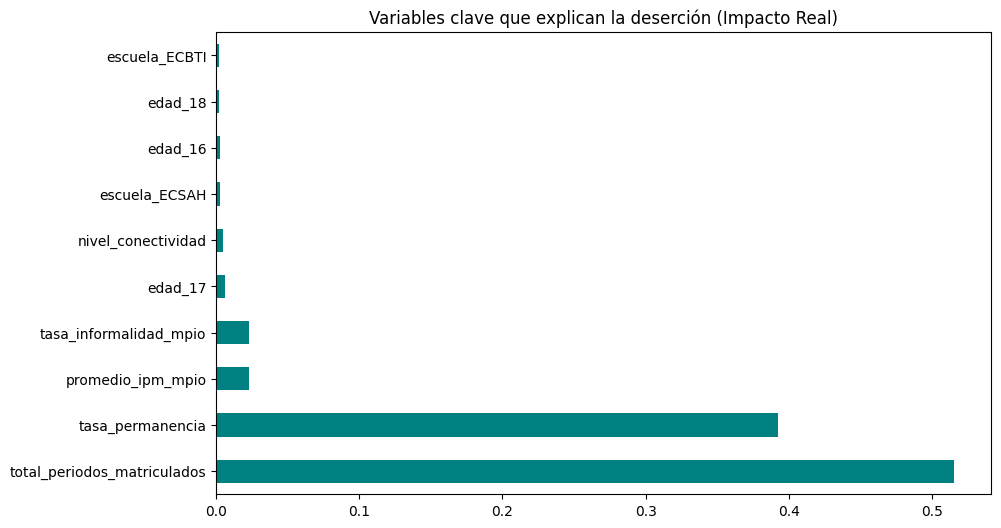

In [2]:
import awswrangler as wr
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS DESDE GOLD
print("Cargando la base maestra completa desde Gold...")
query = 'SELECT * FROM "data_lake_academico_gold"."fact_estudiante_periodo"'
df = wr.athena.read_sql_query(query, database="data_lake_academico_gold")

# 2. LIMPIEZA: Seleccionamos las columnas definitivas
# Incluimos: edad, tasa_permanencia, total_periodos, conectividad y factores socioeconómicos
cols_modelo = [
    'edad', 'tasa_permanencia', 'total_periodos_matriculados', 
    'promedio_ipm_mpio', 'tasa_informalidad_mpio', 'nivel_conectividad',
    'escuela', 'zona', 'desertion_t1'
]
df_clean = df[cols_modelo].dropna()

# 3. TRANSFORMACIÓN: Variables categóricas a numéricas
X = pd.get_dummies(df_clean.drop('desertion_t1', axis=1), drop_first=True)
y = df_clean['desertion_t1']

# 4. ESCALADO: Ajustamos los datos para que el modelo trabaje mejor
# Esto evita que 'edad' (número grande) domine sobre 'tasa_permanencia' (decimal)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. DIVISIÓN: Entrenamiento (70%) y Prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 6. ENTRENAMIENTO (Random Forest Optimizado)
# Ajustamos class_weight manualmente para dar más prioridad a la detección de desertores (clase 1)
print("Entrenando el modelo con variables de contexto y conectividad...")
modelo = RandomForestClassifier(
    n_estimators=300, 
    max_depth=15, 
    class_weight={0: 1, 1: 1.6}, 
    random_state=42
)
modelo.fit(X_train, y_train)

# 7. EVALUACIÓN FINAL
y_pred = modelo.predict(X_test)

print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

# 8. IMPORTANCIA DE VARIABLES (Visualización)
plt.figure(figsize=(10, 6))
importances = pd.Series(modelo.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Variables clave que explican la deserción (Impacto Real)')
plt.show()